# Subscription Conversion Prediction — End-to-End ML Project

## Business Problem
A subscription-based app has many free users, but only a portion of them convert to paid subscriptions. The business wants to **predict which free users are likely to become paid customers** using their engagement behavior.

This can help the business:
- Identify high-potential free users
- Prioritize conversion campaigns
- Personalize offers and messaging
- Improve marketing efficiency
- Understand which engagement signals are associated with conversion

## Machine Learning Problem
This is a **supervised binary classification** problem.

### Target Variable
`Converted`

- `1` → User became a paid subscriber
- `0` → User did not become a paid subscriber

### Input Features
- Age
- Days since signup
- Sessions
- Visits
- Features used
- Average session duration
- Trial days used
- Support interactions

## Models Used
We will train and compare three classification algorithms:

1. **Logistic Regression** — interpretable linear baseline
2. **Decision Tree Classifier** — captures non-linear decision rules
3. **Random Forest Classifier** — ensemble of multiple decision trees

## Evaluation Metrics
Models will be compared using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

## Final Architecture

```text
Raw User Data
      ↓
Data Cleaning
      ↓
EDA
      ↓
Feature Engineering
      ↓
Train / Test Split
      ↓
 ┌────────────────────────────┐
 │ Logistic Regression        │
 │ Decision Tree              │
 │ Random Forest              │
 └────────────────────────────┘
      ↓
Model Evaluation
      ↓
Accuracy | Precision | Recall
F1 | ROC-AUC | Confusion Matrix
      ↓
Select / Tune Model
      ↓
Predict Conversion Probability
```
Pipeline
Data Collection → Data Understanding → Data Cleaning → Outlier Detection & Treatment → EDA → Feature Engineering → Define Target Variable → Feature Selection → Encode Target Variable → Train-Test Split → Feature Standardisation → Model Building → Model Training → Prediction → Model Evaluation → Best Model Selection → Model Interpretation → Prediction & Reporting → Final Output

## 1. Data Source & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


## 2. Data Ingestion
Upload the subscription conversion CSV file in Google Colab.

In [2]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
display(df.head())


Saving subscription_conversion_100_users_dirty.csv to subscription_conversion_100_users_dirty.csv
Dataset shape: (119, 10)


,User_ID,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted
0,U001,46.0,107.0,8.0,9.0,4.0,8.7,20.0,1.0,0
1,U002,32.0,137.0,10.0,13.0,4.0,14.2,26.0,3.0,1
2,U003,25.0,7.0,7.0,18.0,4.0,12.4,4.0,3.0,0
3,U004,38.0,11.0,15.0,9.0,2.0,13.5,0.0,1.0,0
4,U005,36.0,148.0,11.0,16.0,8.0,12.9,16.0,NaN,1


## 3. Data Understanding

In [3]:
# Explore the raw data before making any changes to it
print("Shape of raw data:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(df.describe())

print("\nDuplicate rows found:", df.duplicated().sum())

print("\nMissing values per column:")
display(df.isnull().sum().to_frame("Missing Count"))

print("\nTarget class distribution:")
display(df["Converted"].value_counts().rename({0: "Not Converted", 1: "Converted"}))


Shape of raw data: (119, 10)

Data types:


,Data Type
User_ID,object
Age,float64
Days_Since_Signup,float64
Sessions,float64
Visits,float64
Features_Used,float64
Avg_Session_Minutes,float64
Trial_Days_Used,float64
Support_Interactions,float64
Converted,int64



Summary statistics:


,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted
count,114.000000,116.000000,116.000000,118.000000,118.000000,116.000000,118.000000,116.000000,119.000000
mean,36.324561,99.250000,10.956897,15.059322,4.966102,14.038793,15.186441,1.525862,0.546218
std,10.932209,48.133307,3.025665,3.798993,2.148075,5.911783,8.594322,1.114811,0.499964
min,18.000000,7.000000,4.000000,6.000000,1.000000,2.000000,0.000000,0.000000,0.000000
25%,26.000000,59.750000,9.000000,12.000000,3.000000,9.900000,8.000000,1.000000,0.000000
50%,38.000000,108.000000,11.000000,15.000000,5.000000,13.600000,15.000000,1.000000,1.000000
75%,45.000000,136.000000,13.000000,17.000000,6.000000,18.200000,22.000000,2.000000,1.000000
max,55.000000,178.000000,17.000000,26.000000,11.000000,31.800000,30.000000,5.000000,1.000000



Duplicate rows found: 9

Missing values per column:


,Missing Count
User_ID,0
Age,5
Days_Since_Signup,3
Sessions,3
Visits,1
Features_Used,1
Avg_Session_Minutes,3
Trial_Days_Used,1
Support_Interactions,3
Converted,0



Target class distribution:


,count
Converted,
Converted,65
Not Converted,54


## 4. Data Cleaning

In [4]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Fill missing numerical values with the median
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Shape after cleaning:", df.shape)
print("Total missing values after cleaning:", df.isnull().sum().sum())


Shape after cleaning: (110, 10)
Total missing values after cleaning: 0


## 5. Outlier Detection & Treatment

In [5]:
# Detect outliers using the IQR method and treat them by capping (winsorizing)
# rather than dropping rows, since the dataset is small and every user record matters
outlier_cols = [
    "Age", "Days_Since_Signup", "Sessions", "Visits",
    "Features_Used", "Avg_Session_Minutes", "Trial_Days_Used",
    "Support_Interactions"
]

outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary.append({
        "Feature": col,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outliers Found": n_outliers
    })

    # Cap values outside the IQR bounds
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)
print("\nOutliers capped to the lower/upper IQR bounds shown above.")


,Feature,Lower Bound,Upper Bound,Outliers Found
0,Age,-0.62,70.38,0
1,Days_Since_Signup,-34.00,238.00,0
2,Sessions,3.00,19.00,0
3,Visits,4.50,24.50,2
4,Features_Used,-1.50,10.50,1
5,Avg_Session_Minutes,-1.29,30.21,1
6,Trial_Days_Used,-12.38,42.62,0
7,Support_Interactions,-0.50,3.50,4



Outliers capped to the lower/upper IQR bounds shown above.


## 6. EDA — Exploratory Data Analysis

In [6]:
# Basic dataset overview
print("Data types:")
display(df.dtypes.to_frame("Data Type"))

print("\nTarget distribution:")
display(df["Converted"].value_counts().rename({0: "Not Converted", 1: "Converted"}))

print("\nSummary statistics:")
display(df.describe())


Data types:


,Data Type
User_ID,object
Age,float64
Days_Since_Signup,float64
Sessions,float64
Visits,float64
Features_Used,float64
Avg_Session_Minutes,float64
Trial_Days_Used,float64
Support_Interactions,float64
Converted,int64



Target distribution:


,count
Converted,
Converted,64
Not Converted,46



Summary statistics:


,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted
count,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000
mean,36.072727,101.081818,11.036364,15.018182,5.013636,14.378295,15.281818,1.463636,0.581818
std,10.632915,46.367327,3.019591,3.748350,2.146535,5.665381,8.452926,1.042028,0.495518
min,18.000000,7.000000,4.000000,6.000000,1.000000,2.000000,0.000000,0.000000,0.000000
25%,26.000000,68.000000,9.000000,12.000000,3.000000,10.525000,8.250000,1.000000,0.000000
50%,37.000000,109.000000,11.000000,15.000000,5.000000,14.300000,16.000000,1.000000,1.000000
75%,43.750000,136.000000,13.000000,17.000000,6.000000,18.400000,22.000000,2.000000,1.000000
max,55.000000,178.000000,17.000000,24.500000,10.500000,30.212500,30.000000,3.500000,1.000000


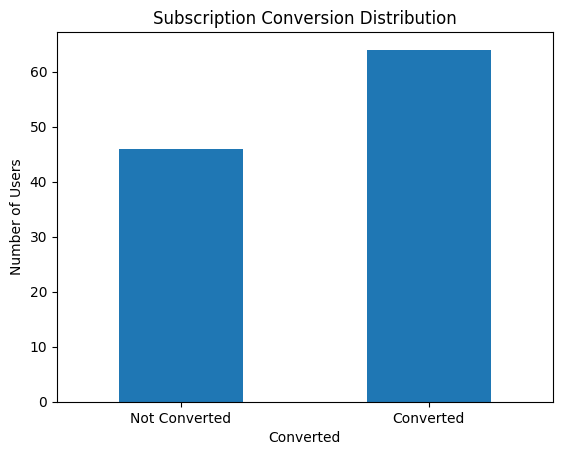

In [7]:
# Target distribution
df["Converted"].value_counts().sort_index().plot(kind="bar")
plt.title("Subscription Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Number of Users")
plt.xticks([0, 1], ["Not Converted", "Converted"], rotation=0)
plt.show()


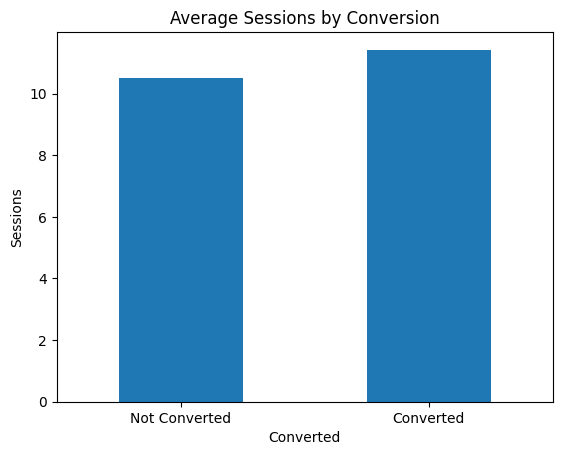

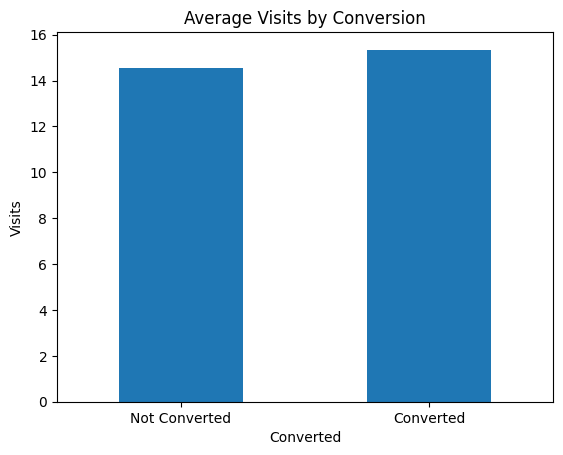

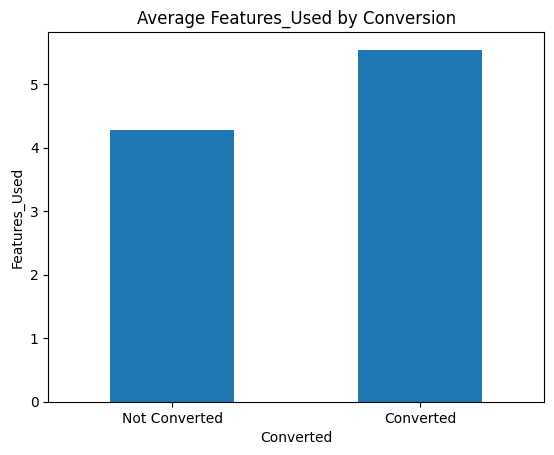

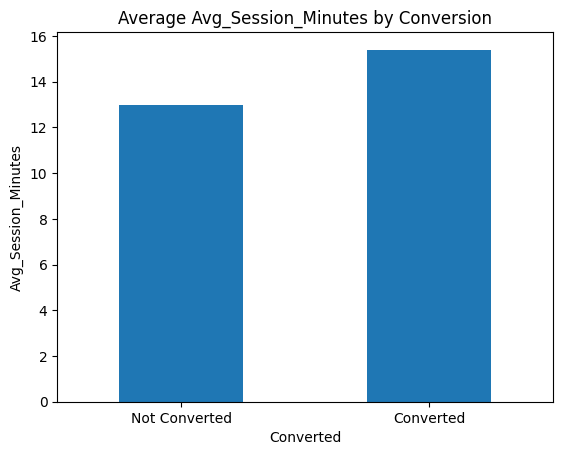

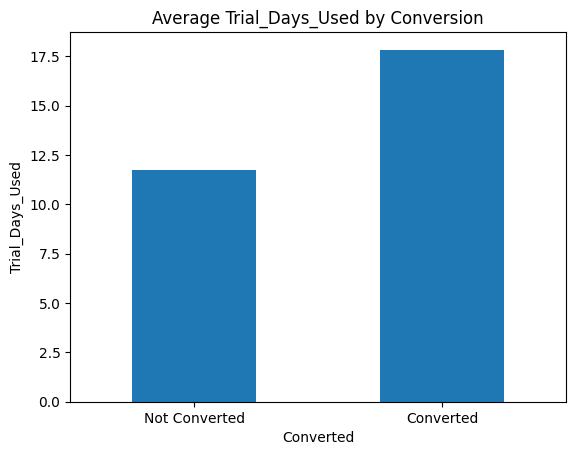

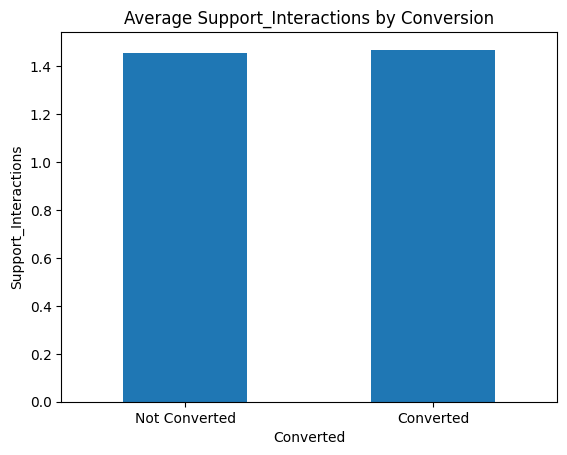

In [8]:
# Relationship between engagement variables and conversion
eda_cols = [
    "Sessions", "Visits", "Features_Used",
    "Avg_Session_Minutes", "Trial_Days_Used",
    "Support_Interactions"
]

for col in eda_cols:
    df.groupby("Converted")[col].mean().plot(kind="bar")
    plt.title(f"Average {col} by Conversion")
    plt.xlabel("Converted")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Not Converted", "Converted"], rotation=0)
    plt.show()


## 7. Feature Engineering

In [9]:
# Create simple engagement-rate features
df["Sessions_Per_Day"] = df["Sessions"] / df["Days_Since_Signup"].clip(lower=1)
df["Visits_Per_Day"] = df["Visits"] / df["Days_Since_Signup"].clip(lower=1)

display(df.head())


,User_ID,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted,Sessions_Per_Day,Visits_Per_Day
0,U001,46.0,107.0,8.0,9.0,4.0,8.7,20.0,1.0,0,0.074766,0.084112
1,U002,32.0,137.0,10.0,13.0,4.0,14.2,26.0,3.0,1,0.072993,0.094891
2,U003,25.0,7.0,7.0,18.0,4.0,12.4,4.0,3.0,0,1.000000,2.571429
3,U004,38.0,11.0,15.0,9.0,2.0,13.5,0.0,1.0,0,1.363636,0.818182
4,U005,36.0,148.0,11.0,16.0,8.0,12.9,16.0,1.0,1,0.074324,0.108108


## 8. Define Target Variable

In [10]:
target = "Converted"
y = df[target]

print("Target variable:", target)
print("\nClass distribution:")
display(y.value_counts().rename({0: "Not Converted", 1: "Converted"}))


Target variable: Converted

Class distribution:


,count
Converted,
Converted,64
Not Converted,46


## 9. Feature Selection

In [11]:
# User_ID is an identifier, not a predictive feature.
# The target ("Converted") was already defined in the previous step.
feature_cols = [
    "Age",
    "Days_Since_Signup",
    "Sessions",
    "Visits",
    "Features_Used",
    "Avg_Session_Minutes",
    "Trial_Days_Used",
    "Support_Interactions",
    "Sessions_Per_Day",
    "Visits_Per_Day"
]

X = df[feature_cols]

print("Selected features:")
print(feature_cols)


Selected features:
['Age', 'Days_Since_Signup', 'Sessions', 'Visits', 'Features_Used', 'Avg_Session_Minutes', 'Trial_Days_Used', 'Support_Interactions', 'Sessions_Per_Day', 'Visits_Per_Day']


## 10. Encode Target Variable

In [12]:
# Converted is already numeric (0/1), but we encode it explicitly with
# LabelEncoder so the pipeline works unchanged even if the raw target were
# provided as text labels (e.g. "Yes"/"No")
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Target classes:", list(le.classes_))
print("Encoded mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Target classes: [np.int64(0), np.int64(1)]
Encoded mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


## 11. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 88
Testing rows: 22


## 12. Feature Standardisation

In [14]:
# Fit the scaler on the training data only, then apply it to both sets
# to avoid leaking test-set information into training
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())


,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Sessions_Per_Day,Visits_Per_Day
17,-1.690042,1.167474,0.297219,0.315009,-0.474534,0.649403,1.116871,1.465904,-0.444650,-0.394684
91,1.386337,0.912384,0.951101,0.315009,-1.890094,1.298035,-0.812644,-0.459463,-0.362290,-0.373180
99,1.482474,1.443823,0.951101,0.315009,0.469172,-1.156246,-0.330265,1.465904,-0.420416,-0.414554
97,0.232695,-1.978643,-1.664427,0.036408,-0.474534,-0.788104,-0.812644,-1.422146,1.971622,3.594935
60,-1.113221,-0.724448,0.624160,-1.077997,-0.474534,0.263731,0.272708,-0.459463,0.025081,-0.242076


## 13. Model Building

In [15]:
# Define the candidate model objects (not yet trained).
# Features are already standardised, so Logistic Regression no longer
# needs its own internal scaling step.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
}

print("Models defined:", list(models.keys()))


Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest']


## 14. Model Training

In [16]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

print("All models trained successfully.")


All models trained successfully.


## 15. Prediction

In [17]:
# Generate predictions and probabilities for every trained model on the test set
predictions = {}

for name, model in models.items():
    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = {"pred": pred, "prob": prob}

print("Predictions generated for:", list(predictions.keys()))


Predictions generated for: ['Logistic Regression', 'Decision Tree', 'Random Forest']


## 16. Model Evaluation

16.a. Confusion Matrix

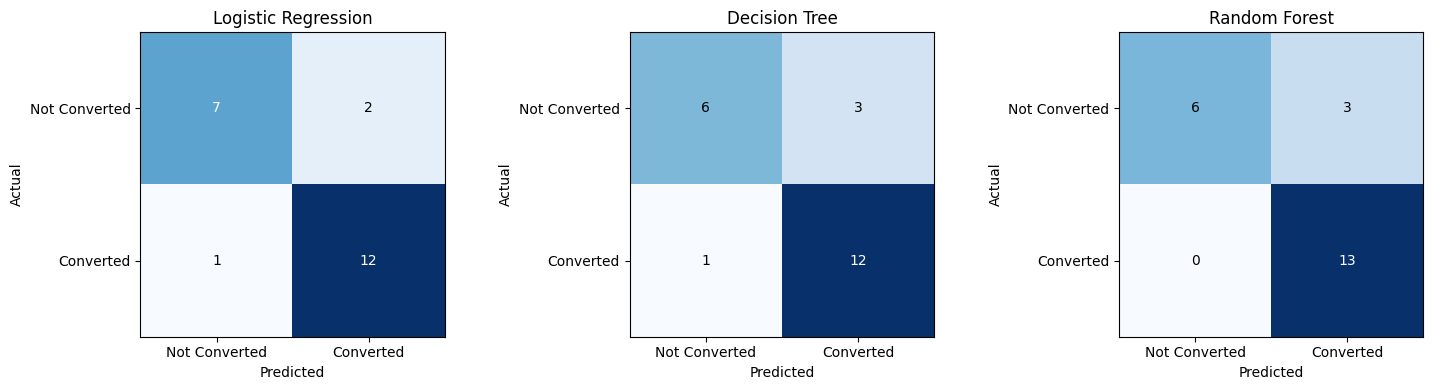

In [28]:
# Confusion Matrix comparison across all trained models
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))

labels = ["Not Converted", "Converted"]

for ax, (name, model) in zip(axes, models.items()):
    pred = predictions[name]["pred"]
    cm = confusion_matrix(y_test, pred)

    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)

    # Annotate each cell with its count
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

16.b. Comparison

In [27]:
results = []

for name, model in models.items():
    pred = predictions[name]["pred"]
    prob = predictions[name]["prob"]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.863636,0.812500,1.000000,0.896552,0.863248
1,Logistic Regression,0.863636,0.857143,0.923077,0.888889,0.837607
2,Decision Tree,0.818182,0.800000,0.923077,0.857143,0.782051


## 17. Best Model Selection

In [19]:
# Select the best model based on F1 Score (change the metric below if a different
# business priority — e.g. Recall to catch more potential converters — is preferred)
selection_metric = "F1 Score"

best_model_name = results_df.sort_values(selection_metric, ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
best_pred = predictions[best_model_name]["pred"]
best_prob = predictions[best_model_name]["prob"]

print(f"Best model selected (by {selection_metric}): {best_model_name}")
print("\nMetrics for selected model:")
display(results_df[results_df["Model"] == best_model_name])


Best model selected (by F1 Score): Random Forest

Metrics for selected model:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.863636,0.8125,1.0,0.896552,0.863248


## 18. Model Interpretation
Understanding *why* the best model makes the predictions it does — which features it relies on, and where its errors occur.

### 18a. Feature Importance (Best Model)

In [20]:
# Works regardless of which model was selected:
# - Tree-based models (Decision Tree, Random Forest) expose feature_importances_
# - Logistic Regression exposes coefficients instead, so we use their
#   absolute value as an importance proxy

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
    importance_label = "Importance"
elif hasattr(best_model, "coef_"):
    importance_values = np.abs(best_model.coef_[0])
    importance_label = "Importance (|coefficient|)"
else:
    raise ValueError("Selected model does not expose feature importances or coefficients.")

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    importance_label: importance_values
}).sort_values(importance_label, ascending=False).reset_index(drop=True)

display(importance_df)


,Feature,Importance
0,Trial_Days_Used,0.201401
1,Avg_Session_Minutes,0.121361
2,Sessions_Per_Day,0.114095
3,Visits_Per_Day,0.112552
4,Sessions,0.096956
5,Features_Used,0.093064
6,Days_Since_Signup,0.084026
7,Age,0.081779
8,Visits,0.054739
9,Support_Interactions,0.040028


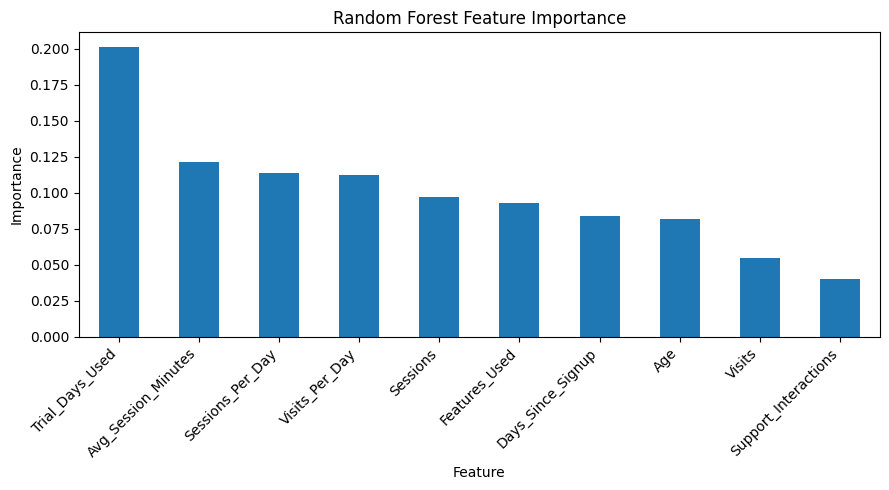

In [21]:
importance_df.plot(
    x="Feature",
    y=importance_label,
    kind="bar",
    legend=False,
    figsize=(9, 5)
)
plt.title(f"{best_model_name} Feature Importance")
plt.xlabel("Feature")
plt.ylabel(importance_label)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 18b. Confusion Matrix (Best Model)

In [22]:
print("Selected model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred)
print("Confusion Matrix (raw counts):")
print(cm)


Selected model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.81      1.00      0.90        13

    accuracy                           0.86        22
   macro avg       0.91      0.83      0.85        22
weighted avg       0.89      0.86      0.86        22

Confusion Matrix (raw counts):
[[ 6  3]
 [ 0 13]]


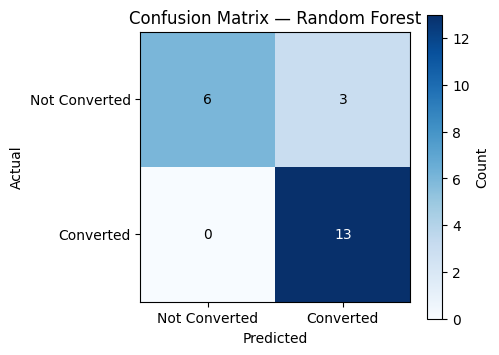

In [23]:
# Visual confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

labels = ["Not Converted", "Converted"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name}")

# Annotate each cell with its count
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()


## 19. Prediction & Reporting

In [24]:
# Predict conversion probability for the test users
# (original, unscaled feature values are used here so the report stays human-readable)
prediction_output = X_test.copy()
prediction_output["Actual_Converted"] = y_test
prediction_output["Predicted_Converted"] = best_pred
prediction_output["Conversion_Probability"] = best_prob

display(prediction_output.head(10))


,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Sessions_Per_Day,Visits_Per_Day,Actual_Converted,Predicted_Converted,Conversion_Probability
4,36.0,148.0,11.0,16.0,8.0,12.9,16.0,1.0,0.074324,0.108108,1,1,0.818891
8,41.0,21.0,14.0,10.0,8.0,19.9,9.0,0.0,0.666667,0.476190,1,1,0.526667
84,50.0,129.0,16.0,20.0,3.0,9.0,25.0,3.0,0.124031,0.155039,1,1,0.761854
20,29.0,35.0,12.0,16.0,3.0,14.7,24.0,2.0,0.342857,0.457143,1,1,0.529405
39,37.0,134.0,6.0,18.0,6.0,15.3,22.0,0.0,0.044776,0.134328,1,1,0.720833
93,40.0,103.0,11.0,10.0,2.0,16.3,8.0,1.0,0.106796,0.097087,0,0,0.428881
50,21.0,68.0,5.0,23.0,6.0,4.2,21.0,3.0,0.073529,0.338235,0,1,0.505000
85,22.0,151.0,14.0,17.0,6.0,17.1,29.0,1.0,0.092715,0.112583,0,1,0.913323
90,29.0,104.0,9.0,13.0,6.0,16.2,30.0,0.0,0.086538,0.125000,1,1,0.840456
38,19.0,81.0,9.0,17.0,6.0,11.0,27.0,1.0,0.111111,0.209877,1,1,0.784206


In [25]:
# Simple business segmentation
prediction_output["Segment"] = pd.cut(
    prediction_output["Conversion_Probability"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=["Low Potential", "Medium Potential", "High Potential"]
)

display(
    prediction_output[
        ["Actual_Converted", "Predicted_Converted", "Conversion_Probability", "Segment"]
    ].head(10)
)


,Actual_Converted,Predicted_Converted,Conversion_Probability,Segment
4,1,1,0.818891,High Potential
8,1,1,0.526667,Medium Potential
84,1,1,0.761854,High Potential
20,1,1,0.529405,Medium Potential
39,1,1,0.720833,High Potential
93,0,0,0.428881,Medium Potential
50,0,1,0.505000,Medium Potential
85,0,1,0.913323,High Potential
90,1,1,0.840456,High Potential
38,1,1,0.784206,High Potential


## 20. Final Output

### Business Objective
Predict which free users are likely to convert to paid subscribers.

### Final Pipeline
**Data Collection → Data Understanding → Data Cleaning → Outlier Detection & Treatment → EDA → Feature Engineering → Define Target Variable → Feature Selection → Encode Target Variable → Train-Test Split → Feature Standardisation → Model Building → Model Training → Prediction → Model Evaluation → Best Model Selection → Model Interpretation → Prediction & Reporting → Final Output**

### Output
The project produces:
- Raw-data understanding (shape, types, missing values, duplicates, class balance)
- Cleaned data (duplicates removed, missing values imputed)
- Outlier-treated features (capped using the IQR method)
- EDA insights
- Engineered features
- An explicitly defined and encoded target variable
- Selected input features
- Standardised features (fit on training data only)
- Model objects, trained
- Test-set predictions for every candidate model
- Model evaluation metrics for all candidate models
- The selected best-performing model
- Feature importance and a confusion matrix (report + heatmap) for the selected model
- Final conversion predictions, probabilities, and business segmentation
